# M-PESA FRAUD DETECTION — MODELLING

This notebook covers the full modelling pipeline for the M-Pesa Fraud Detection project. The engineered dataset from the feature engineering notebook is loaded here and taken through preprocessing, model training, evaluation, and hyperparameter tuning.

## PIPELINE OVERVIEW

1. **Preprocessing** — encoding categorical features, feature scaling for Logistic Regression, train/test split
2. **Base Model Training** — four classifiers trained on consistent splits for fair comparison
3. **Evaluation** — each model evaluated on the holdout test split and the final unseen evaluation set
4. **Tuning** — best performing base model tuned using GridSearchCV and Optuna
5. **Final Evaluation** — tuned model evaluated against `evaluation.csv` — the final unseen dataset

---

## PREPROCESSING DECISIONS

### Categorical Encoding
Three categorical columns require encoding before modelling:

| Column | Unique Values | Encoding Strategy | Reason |
|---|---|---|---|
| `region` | 5 (Nairobi, Mombasa, Kisumu, Nakuru, Eldoret) | One-Hot Encoding | Nominal — no ordinal relationship between cities |
| `transaction_type` | 3 (peer, till, paybill) | One-Hot Encoding | Nominal — no ordinal relationship between types |
| `device_type` | 2 (smartphone, feature) | Binary Encoding (0/1) | Two categories — one-hot would produce perfectly inverse columns |

### Feature Scaling
Only **Logistic Regression** requires feature scaling. Tree-based models (Random Forest, XGBoost, LightGBM) make decisions based on feature split thresholds, not feature magnitude — scaling has no effect on their performance. Applying a `StandardScaler` to all models would be unnecessary overhead and adds no value beyond Logistic Regression.

### Class Imbalance
The dataset is heavily imbalanced — **97.07% legitimate vs 2.93% fraudulent** transactions. Two strategies are applied at different stages:

- **Base models:** `class_weight='balanced'` passed as a parameter to each classifier. This adjusts the loss function to penalise misclassification of the minority class (fraud) more heavily — a one-line adjustment that establishes a fair baseline without modifying the dataset.
- **Best model (post-selection):** SMOTE (Synthetic Minority Oversampling Technique) applied to the training data only, after the train/test split. SMOTE generates synthetic fraud samples by interpolating between existing fraud cases, giving the model more fraud patterns to learn from.

> **Important:** SMOTE is applied **after** splitting into train and test sets. Applying it before splitting would allow synthetic samples — generated from training data — to appear in the test set, producing artificially inflated evaluation metrics on data that is no longer truly unseen.

> **Synthetic-on-synthetic caveat:** Since the underlying dataset is itself synthetically generated, SMOTE interpolates between artificially placed fraud cases rather than real ones. This may amplify existing distributional artifacts in the data and inflate model confidence beyond what would be achievable on real M-Pesa transaction data. This limitation is documented in the model card.

---

## MODEL SELECTION

Four classifiers are compared in this notebook:

| Model | Scaling Required | Class Weight Support | Notes |
|---|---|---|---|
| Logistic Regression |  Yes |  `class_weight='balanced'` | Baseline model — linear decision boundary |
| Random Forest |  No |  `class_weight='balanced'` | Ensemble of decision trees — handles non-linear relationships |
| XGBoost |  No |  `scale_pos_weight` | Gradient boosting — strong on tabular data |
| LightGBM |  No |  `class_weight='balanced'` | Fast gradient boosting — efficient on large datasets |

All four models are trained on identical train/test splits to ensure fair comparison.

---

## EVALUATION METRICS

Given the class imbalance, **accuracy is not a meaningful metric** — a model predicting every transaction as legitimate would achieve 97% accuracy while catching zero fraud. The following metrics are used instead:

| Metric | Why It Matters Here |
|---|---|
| **Precision** | Of all transactions flagged as fraud, how many actually were? — minimises false alarms |
| **Recall** | Of all actual fraud cases, how many did the model catch? — minimises missed fraud |
| **F1 Score** | Harmonic mean of precision and recall — overall fraud detection performance |
| **AUC-ROC** | Model's ability to distinguish fraud from legitimate across all thresholds |

Recall is prioritised over precision in this context — a missed fraud transaction (false negative) causes direct financial loss to the customer, whereas a false alarm (false positive) causes friction but no monetary harm.

---

## TUNING STRATEGY

Hyperparameter tuning is applied to the **best performing base model only**. Tuning all four models is computationally expensive and unnecessary once a clear winner is identified.

Two tuning approaches are used sequentially:

1. **GridSearchCV** — exhaustive search over a defined parameter grid with cross-validation. Establishes a tuned baseline and refreshes understanding of the search process.
2. **Optuna (Bayesian Optimisation)** — probabilistic search that learns from previous trials to focus on promising parameter regions. More efficient than GridSearchCV on large parameter spaces. Results compared against GridSearchCV to quantify the efficiency gain.

---

## EVALUATION SETS

Each model is evaluated at two stages:

1. **Test split (20%)** — held out from `training.csv` during the 80-20 train/test split. Used for model comparison and selection.
2. **`evaluation.csv` (10,000 rows)** — completely unseen data carved out before any modelling began, with the original 97/3 class ratio preserved via stratification. Acts as the final real-world performance benchmark — no model decisions are made based on this set until the very end.

In [97]:
# LIBRARY IMPORTATION
# General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector

#Classbalancing
from imblearn.over_sampling import SMOTE

#Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

#Tunning
from sklearn.model_selection import GridSearchCV
import optuna

# Evaluation
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                            f1_score, auc, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay)

# Model saving
import joblib

In [98]:
# data Loading
df = pd.read_csv('../Data/training.csv')
eval_df = pd.read_csv('../Data/evaluation.csv')

print('TRAINING DATASET OVERVIEW')
print(f'='*100)
print(df.head())
print(f'='*100)
print('EVALAUTION DATASET OVERVIEW')
print(f'='*100)
print(eval_df.head())

TRAINING DATASET OVERVIEW
    amount  sender_balance_before transaction_type device_type   region  \
0   630.50               70062.43             till     feature   Nakuru   
1  2094.43               40608.35             till     feature   Nakuru   
2     9.25               61559.02          paybill     feature   Nakuru   
3  3124.94               51621.32             peer  smartphone  Mombasa   
4  2323.89               14156.01          paybill  smartphone  Nairobi   

   is_fraud  hour_sin  hour_cos       day_sin   day_cos  month_2026_sin  \
0         0 -0.500000 -0.866025 -2.449294e-16  1.000000        0.866025   
1         0  0.866025  0.500000  4.338837e-01 -0.900969        0.500000   
2         0 -0.707107 -0.707107  4.338837e-01 -0.900969        0.500000   
3         0  0.707107  0.707107 -7.818315e-01  0.623490        0.500000   
4         0 -0.500000  0.866025 -9.749279e-01 -0.222521       -0.866025   

   month_2026_cos  drain_rate  account_emptied  
0       -0.500000    0.

### LOGISTIC REGRESSOR

In [114]:
# Variable declaration
x = df.drop(columns=['is_fraud'])
y = df['is_fraud']

print(x.columns)

Index(['amount', 'sender_balance_before', 'transaction_type', 'device_type',
       'region', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'month_2026_sin', 'month_2026_cos', 'drain_rate', 'account_emptied'],
      dtype='str')


In [115]:
# Mapping deveice type to 1 or 0
x['device_type'] = x['device_type'].map({'smartphone': 0, 'feature': 1})
x['device_type'].value_counts()

device_type
1    55251
0    54664
Name: count, dtype: int64

In [116]:
# Using the ColumnTranformer for encoding
encoder = ColumnTransformer(
    transformers = [('cat', OneHotEncoder(), make_column_selector(dtype_include=['object', 'category']))]
)

x_encoded = encoder.fit_transform(x)
x_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 219830 stored elements and shape (109915, 8)>

In [117]:
# scaling the feature variables
scaler = StandardScaler(with_mean=False)
x_scaled = scaler.fit_transform(x_encoded)
x_scaled

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 219830 stored elements and shape (109915, 8)>

Train Prediction Summary Report
              precision    recall  f1-score   support

           0       0.97      0.53      0.69     85360
           1       0.03      0.49      0.06      2572

    accuracy                           0.53     87932
   macro avg       0.50      0.51      0.37     87932
weighted avg       0.94      0.53      0.67     87932

Test Prediction Summary Report
              precision    recall  f1-score   support

           0       0.97      0.53      0.68     21340
           1       0.03      0.47      0.05       643

    accuracy                           0.52     21983
   macro avg       0.50      0.50      0.37     21983
weighted avg       0.94      0.52      0.66     21983



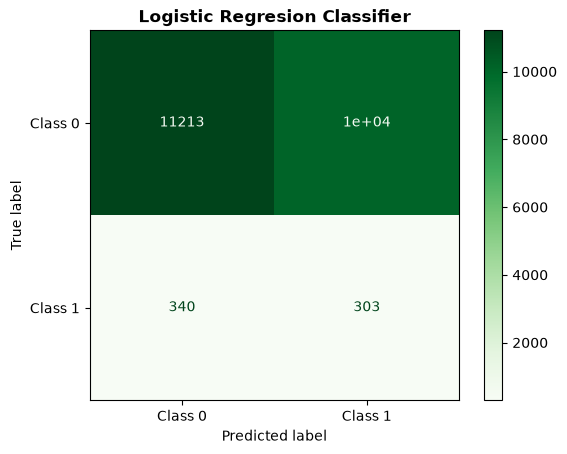

In [118]:
# Train test split 
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42,stratify=y)

#Model Initialization
log_classifier = LogisticRegression(class_weight='balanced', random_state=42)
log_classifier.fit(X_train, y_train)
# Predictions
y_train_pred = log_classifier.predict(X_train)
y_pred = log_classifier.predict(X_test)

# Evaluations
train_report = classification_report(y_train, y_train_pred)
test_report = classification_report(y_test, y_pred)
print('Train Prediction Summary Report')
print(f'='*100)
print(train_report)
print(f'='*100)
print('Test Prediction Summary Report')
print(f'='*100)
print(test_report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Logistic Regresion Classifier', weight = 'bold')
plt.show()